<a href="https://colab.research.google.com/github/rounak-roy-2025/Finance101/blob/Volatiltiy/RNN_Volatility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NIFTY50 VOLATILITY PREDICTION - RNN MODEL

[1/6] Fetching NIFTY50 data...


/tmp/ipython-input-1392901312.py:29: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty = yf.download('^NSEI', period=period, progress=False)


✓ Downloaded 493 days of NIFTY50 data from Yahoo Finance

[2/6] Calculating historical volatility...
✓ Volatility range: 0.0502 to 0.2999

[3/6] Normalizing data...

[4/6] Preparing sequences (lookback=10)...
✓ Training samples: 370, Test samples: 93

[5/6] Training RNN model (50 epochs)...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.2948 - mae: 0.4105 - val_loss: 0.0142 - val_mae: 0.1035
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1210 - mae: 0.2626 - val_loss: 0.0081 - val_mae: 0.0764
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0771 - mae: 0.2042 - val_loss: 0.0028 - val_mae: 0.0440
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0698 - mae: 0.2019 - val_loss: 0.0013 - val_mae: 0.0304
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0340 - mae: 0.1399 - val_loss: 0.0025 - val_mae: 0.0430
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0489 - mae: 0.1562 - val_loss: 0.0051 - val_mae: 0.0663
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0370 - mae: 0.1440 - val_loss: 0.0013 - val_mae: 0.0305
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0275 - mae: 0.1238 - val_loss: 0.0031 - val_mae: 0.0520
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0238 - mae: 0.116

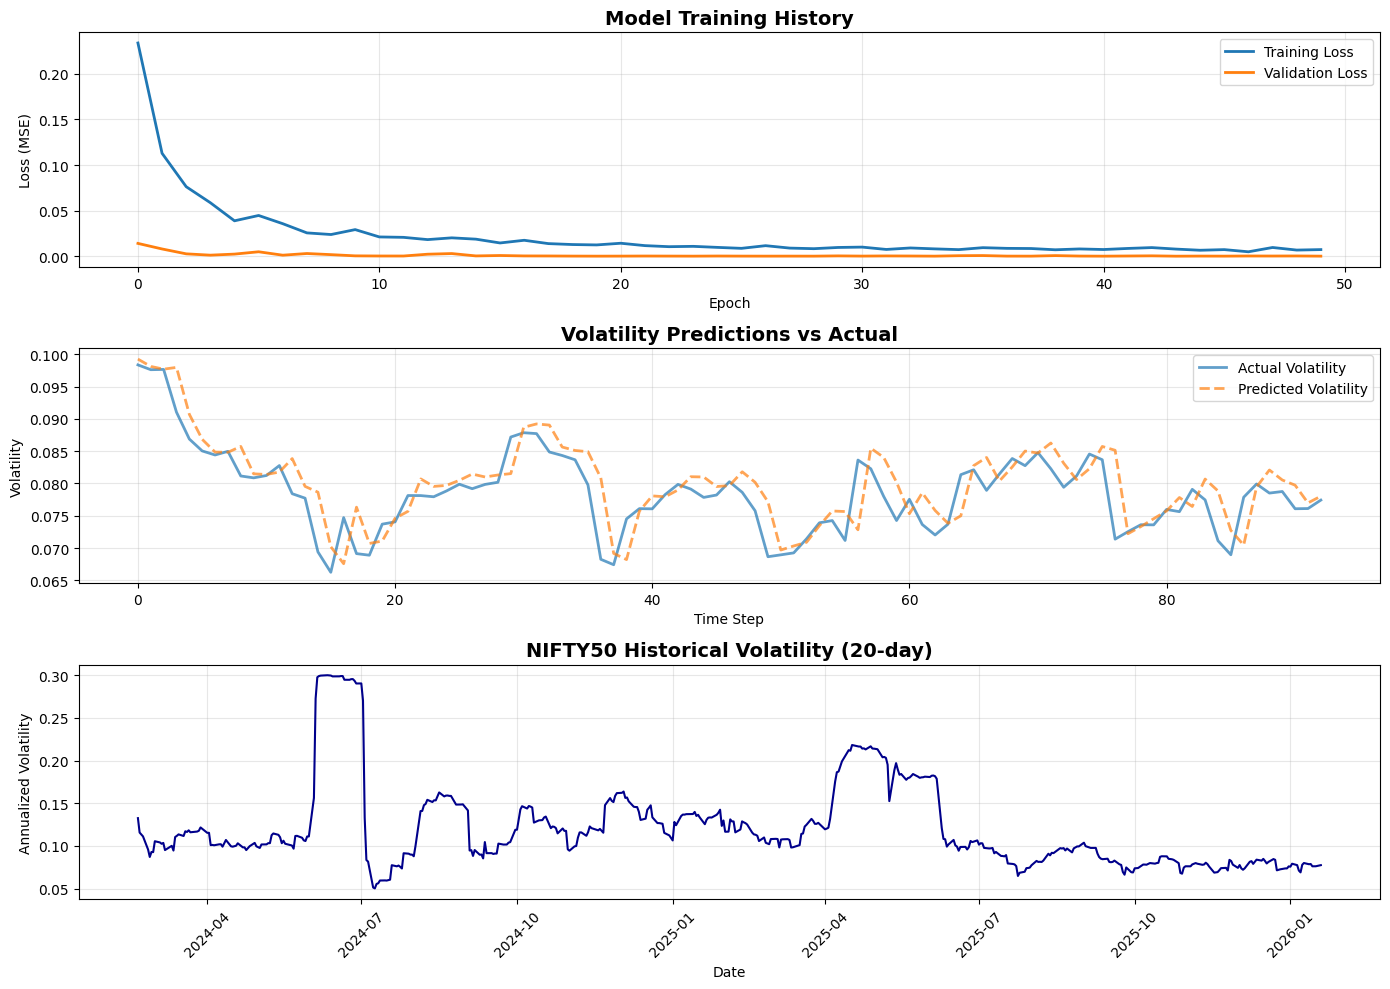

✓ Model saved as 'nifty50_volatility_rnn_model.h5'


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import yfinance as yf
from datetime import datetime, timedelta

# TensorFlow/Keras for RNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# =============================================================================
# 1. DATA FETCHING
# =============================================================================

def fetch_nifty_data(source='yfinance', period='2y'):
    """
    Fetch NIFTY50 data from different sources

    Parameters:
    - source: 'yfinance' or 'nse'
    - period: data period (e.g., '2y', '5y', '1y')
    """

    if source == 'yfinance':
        # Using Yahoo Finance
        nifty = yf.download('^NSEI', period=period, progress=False)
        df = nifty[['Close']].copy()
        df.columns = ['Close']
        print(f"✓ Downloaded {len(df)} days of NIFTY50 data from Yahoo Finance")

    elif source == 'nse':
        # Using NSE India (alternative method with nsepy)
        try:
            from nsepy import get_history
            from datetime import date

            end_date = date.today()
            start_date = end_date - timedelta(days=730)  # 2 years

            # Fetch NIFTY 50 index data
            nifty = get_history(symbol="NIFTY 50",
                               start=start_date,
                               end=end_date,
                               index=True)
            df = nifty[['Close']].copy()
            print(f"✓ Downloaded {len(df)} days of NIFTY50 data from NSE")

        except ImportError:
            print("⚠ nsepy not installed. Install with: pip install nsepy")
            print("Falling back to yfinance...")
            return fetch_nifty_data(source='yfinance', period=period)

    else:
        raise ValueError("Source must be 'yfinance' or 'nse'")

    return df

# =============================================================================
# 2. VOLATILITY CALCULATION
# =============================================================================

def calculate_volatility(df, window=20):
    """
    Calculate historical volatility using rolling window

    Parameters:
    - df: DataFrame with 'Close' prices
    - window: rolling window for volatility calculation
    """
    # Calculate log returns
    df['Returns'] = np.log(df['Close'] / df['Close'].shift(1))

    # Calculate rolling volatility (annualized)
    df['Volatility'] = df['Returns'].rolling(window=window).std() * np.sqrt(252)

    # Drop NaN values
    df = df.dropna()

    return df

# =============================================================================
# 3. DATA PREPARATION
# =============================================================================

def prepare_sequences(data, lookback=10):
    """
    Prepare sequences for RNN training

    Parameters:
    - data: array of volatility values
    - lookback: number of previous time steps to use
    """
    X, y = [], []

    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])

    return np.array(X), np.array(y)

# =============================================================================
# 4. BUILD RNN MODEL
# =============================================================================

def build_rnn_model(input_shape):
    """
    Build Simple RNN model for volatility prediction
    """
    model = Sequential([
        SimpleRNN(32, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        SimpleRNN(16, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])

    return model

# =============================================================================
# 5. MAIN TRAINING PIPELINE
# =============================================================================

def train_volatility_model(source='yfinance', lookback=10, epochs=50):
    """
    Complete pipeline for training volatility prediction model
    """

    print("=" * 70)
    print("NIFTY50 VOLATILITY PREDICTION - RNN MODEL")
    print("=" * 70)

    # Step 1: Fetch data
    print("\n[1/6] Fetching NIFTY50 data...")
    df = fetch_nifty_data(source=source, period='2y')

    # Step 2: Calculate volatility
    print("\n[2/6] Calculating historical volatility...")
    df = calculate_volatility(df, window=20)
    print(f"✓ Volatility range: {df['Volatility'].min():.4f} to {df['Volatility'].max():.4f}")

    # Step 3: Normalize data
    print("\n[3/6] Normalizing data...")
    scaler = MinMaxScaler()
    volatility_scaled = scaler.fit_transform(df['Volatility'].values.reshape(-1, 1))

    # Step 4: Prepare sequences
    print(f"\n[4/6] Preparing sequences (lookback={lookback})...")
    X, y = prepare_sequences(volatility_scaled, lookback=lookback)

    # Reshape for RNN [samples, time steps, features]
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # Train-test split (80-20)
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    print(f"✓ Training samples: {len(X_train)}, Test samples: {len(X_test)}")

    # Step 5: Build and train model
    print(f"\n[5/6] Training RNN model ({epochs} epochs)...")
    model = build_rnn_model(input_shape=(lookback, 1))

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=16,
        validation_data=(X_test, y_test),
        verbose=1
    )

    # Step 6: Evaluate model
    print("\n[6/6] Evaluating model...")
    y_pred = model.predict(X_test)

    # Inverse transform predictions
    y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
    y_pred_actual = scaler.inverse_transform(y_pred)

    # Calculate metrics
    mse = mean_squared_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_actual, y_pred_actual)

    print("\n" + "=" * 70)
    print("MODEL PERFORMANCE METRICS")
    print("=" * 70)
    print(f"Mean Squared Error (MSE):       {mse:.6f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
    print(f"Mean Absolute Error (MAE):      {mae:.6f}")
    print("=" * 70)

    # =============================================================================
    # 7. VISUALIZATION
    # =============================================================================

    # Plot 1: Training History
    plt.figure(figsize=(14, 10))

    plt.subplot(3, 1, 1)
    plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    plt.title('Model Training History', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 2: Predictions vs Actual
    plt.subplot(3, 1, 2)
    plt.plot(y_test_actual, label='Actual Volatility', linewidth=2, alpha=0.7)
    plt.plot(y_pred_actual, label='Predicted Volatility', linewidth=2, alpha=0.7, linestyle='--')
    plt.title('Volatility Predictions vs Actual', fontsize=14, fontweight='bold')
    plt.xlabel('Time Step')
    plt.ylabel('Volatility')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 3: Historical Volatility
    plt.subplot(3, 1, 3)
    plt.plot(df.index, df['Volatility'], linewidth=1.5, color='darkblue')
    plt.title('NIFTY50 Historical Volatility (20-day)', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Annualized Volatility')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.savefig('nifty50_volatility_rnn.png', dpi=300, bbox_inches='tight')
    print("\n✓ Plots saved as 'nifty50_volatility_rnn.png'")
    plt.show()

    # Save model
    model.save('nifty50_volatility_rnn_model.h5')
    print("✓ Model saved as 'nifty50_volatility_rnn_model.h5'")

    return model, history, df, scaler

# =============================================================================
# RUN THE MODEL
# =============================================================================

if __name__ == "__main__":
    # Train model using Yahoo Finance data
    model, history, df, scaler = train_volatility_model(
        source='yfinance',  # or 'nse'
        lookback=10,
        epochs=50
    )

    # To use NSE data instead, uncomment:
    # model, history, df, scaler = train_volatility_model(
    #     source='nse',
    #     lookback=10,
    #     epochs=50
    # )
